<h1>Mode 20</h1>

In [27]:
import json
from matplotlib import pyplot as plt
import pandas as pd

In [38]:
windowSize = 500
RuleBasedResults = 'results_experiment_rule_based.json'
SequentialResults = 'results_experiment_sequential_rollout.json'
AsyncAuto_11_OLDMSE_20 = 'cross_11_on_20_asyncAuto_2agent.json'

def findMovingAvg(inputDF,window):
    movingAvgList = []
    for i in range(inputDF.shape[0] - window):
        newDF = inputDF.loc[i:i + window]
        epi = inputDF.iloc[i]['episode']
        meanVal = newDF['steps'].mean()
        movingAvgList.append({'episode':epi, 'smoothed_steps':meanVal})
    dfMovingAvg = pd.DataFrame(movingAvgList)
    return dfMovingAvg

<h3>Load rule based plot</h3>


In [29]:
with open(RuleBasedResults, 'r') as file:
        data = json.load(file)
listOfWholeTraining = []
epochs = list(data.keys())

i = 0
for trainEpoch in epochs:
    epochData = data[str(trainEpoch)]
    for indData in epochData:
        steps = indData['StepsToSolve']
        listOfWholeTraining.append({"episode": i, "steps": steps})
        i += 1

dfBasePolicy = findMovingAvg(pd.DataFrame(listOfWholeTraining), windowSize)

<h3>Load Sequential Rollout  plot</h3>

In [30]:
with open(SequentialResults, 'r') as file:
        data = json.load(file)
listOfWholeTraining = []
epochs = list(data.keys())

i = 0
for trainEpoch in epochs:
    epochData = data[str(trainEpoch)]
    for indData in epochData:
        steps = indData['StepsToSolve']
        listOfWholeTraining.append({"episode": i, "steps": steps})
        i += 1

dfSeqRollout = findMovingAvg(pd.DataFrame(listOfWholeTraining), windowSize)


<h3>Load Cross Async Auto Trained on mode 11 OLD MSE deployed on Mode 20 plot</h3>

In [40]:
# OLD MSE Loss Function
with open(AsyncAuto_11_OLDMSE_20, 'r') as file:
        data = json.load(file)
listOfWholeTraining = []
listofCorrectCount = []
epochs = list(data.keys())
i = 0
for trainEpoch in epochs:
    epochData = data[str(trainEpoch)]
    stepHist = epochData['stepsHistory']
    correctCount = epochData['correctPredCounter']
    listofCorrectCount.append(correctCount)
    epiCount = len(stepHist)
    for indData in stepHist:
        steps = indData['StepsToSolve']
        listOfWholeTraining.append({"episode": i, "steps": steps})
        i += 1

dfAsyncAuto_11OLDMSE_on_20 = findMovingAvg(pd.DataFrame(listOfWholeTraining),windowSize)
correctCount_MSE = listofCorrectCount

<h2>Plots</h2>

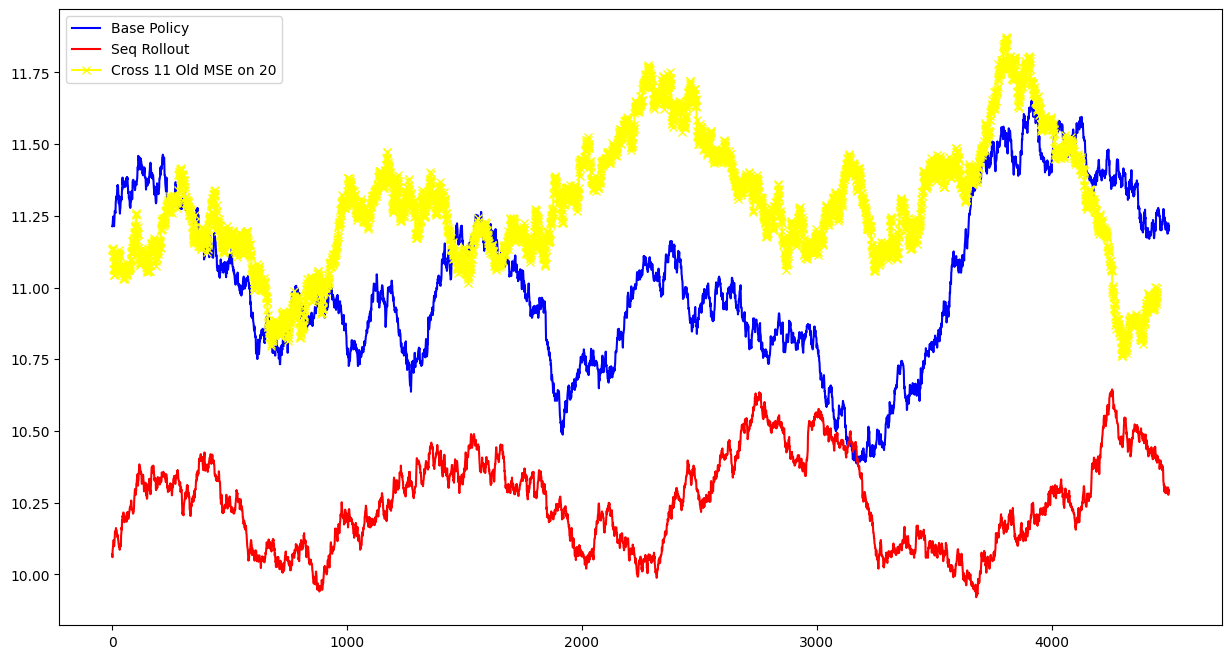

In [42]:
plt.figure(figsize=(15, 8))
plt.plot(dfBasePolicy['episode'], dfBasePolicy['smoothed_steps'], label='Base Policy', color='blue', linestyle='-')
plt.plot(dfSeqRollout['episode'], dfSeqRollout['smoothed_steps'], label='Seq Rollout', color='red', linestyle='-')
plt.plot(dfAsyncAuto_11OLDMSE_on_20['episode'], dfAsyncAuto_11OLDMSE_on_20['smoothed_steps'], label='Cross 11 Old MSE on 20', color='yellow', linestyle='-', marker='x')
plt.legend()

<h2> Training Plots</h2>

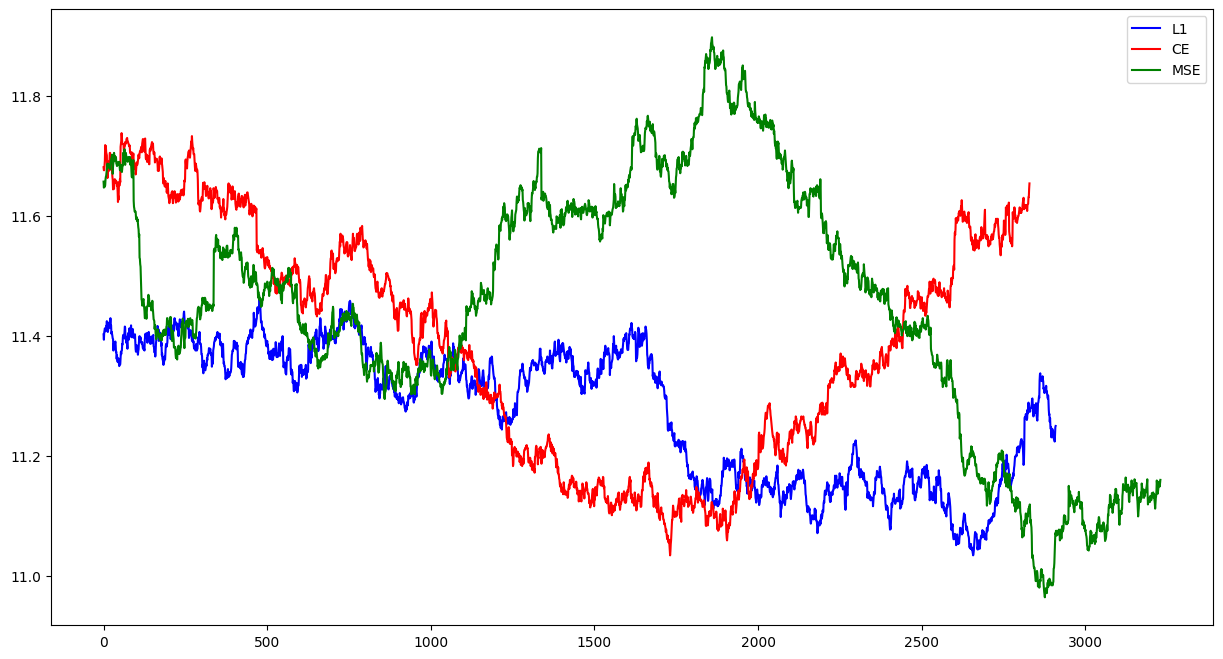

In [47]:
windowSize = 1000
training_L1_loss = 'trainingEvaluations_2agent_L1.json'
training_CE_loss = 'trainingEvaluations_2agent_CE.json'
training_MSE_loss = 'trainingEvaluations_2agent_MSE.json'

def findMovingAvg(inputDF,window):
    movingAvgList = []
    for i in range(inputDF.shape[0] - window):
        newDF = inputDF.loc[i:i + window]
        epi = inputDF.iloc[i]['episode']
        meanVal = newDF['steps'].mean()
        movingAvgList.append({'episode':epi, 'smoothed_steps':meanVal})
    dfMovingAvg = pd.DataFrame(movingAvgList)
    return dfMovingAvg


# Load performance evaluations during training with L1 loss function
with open(training_L1_loss, 'r') as file:
        data = json.load(file)
listOfWholeTraining = []
epochs = list(data.keys())
i = 0
for trainEpoch in epochs:
    epochData = data[str(trainEpoch)]
    for indData in epochData:
        steps = indData['StepsToSolve']
        listOfWholeTraining.append({"episode": i, "steps": steps})
        i += 1
dfTrainingLoss_L1 = findMovingAvg(pd.DataFrame(listOfWholeTraining),windowSize)

# Load performance evaluations during training with CE loss function
with open(training_CE_loss, 'r') as file:
        data = json.load(file)
listOfWholeTraining = []
epochs = list(data.keys())
i = 0
for trainEpoch in epochs:
    epochData = data[str(trainEpoch)]
    for indData in epochData:
        steps = indData['StepsToSolve']
        listOfWholeTraining.append({"episode": i, "steps": steps})
        i += 1
dfTrainingLoss_CE = findMovingAvg(pd.DataFrame(listOfWholeTraining),windowSize)

# Load performance evaluations during training with MSE loss function
with open(training_MSE_loss, 'r') as file:
        data = json.load(file)
listOfWholeTraining = []
epochs = list(data.keys())
i = 0
for trainEpoch in epochs:
    epochData = data[str(trainEpoch)]
    for indData in epochData:
        steps = indData['StepsToSolve']
        listOfWholeTraining.append({"episode": i, "steps": steps})
        i += 1
dfTrainingLoss_MSE = findMovingAvg(pd.DataFrame(listOfWholeTraining),windowSize)


plt.figure(figsize=(15, 8))
plt.plot(dfTrainingLoss_L1['episode'], dfTrainingLoss_L1['smoothed_steps'], label='L1', color='blue', linestyle='-')
plt.plot(dfTrainingLoss_CE['episode'], dfTrainingLoss_CE['smoothed_steps'], label='CE', color='red', linestyle='-')
plt.plot(dfTrainingLoss_MSE['episode'], dfTrainingLoss_MSE['smoothed_steps'], label='MSE', color='green', linestyle='-')
plt.legend()